# Cluster Summary — iGEM

Cluster-level summaries for iGEM teams topic model using year-based normalization (no citation metrics).

Output:
- `assets/reports/cluster_summary_igem.tsv`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

In [2]:
# Load iGEM metadata and topic model outputs
igem = pd.read_csv(os.path.join(ASSETS, 'igem.txt'), sep='\t')
teams_doc_topics = pd.read_csv(os.path.join(MODELS, 'teams_doc_topics.txt'), sep='\t')
teams_topic_names = pd.read_csv(os.path.join(MODELS, 'teams_topic_names.txt'), sep='\t')

igem['Year_y'] = pd.to_numeric(igem['Year_y'], errors='coerce')
igem = igem.rename(columns={'Year_y': 'year'})

# Merge topic assignments and names
igem_topics = igem.merge(teams_doc_topics, on='UT', how='left')
igem_topics = igem_topics.merge(teams_topic_names[['topic', 'global_name']], on='topic', how='left')

print(f"iGEM rows: {len(igem_topics):,}")
print(f"Topics: {igem_topics['topic'].nunique()} (incl. outlier -1)")
igem_topics[['UT', 'year', 'topic', 'global_name']].head(3)

iGEM rows: 3,811
Topics: 154 (incl. outlier -1)


,UT,year,topic,global_name
0,5260,2024,45,Space Synthetic Biology
1,5794,2025,118,Diagnostic Technologies in Synthetic Biology
2,4831,2023,111,Mercury Detection and Detoxification


In [3]:
# Compute year-normalized metrics by topic (exclude outlier -1)
igem_valid = igem_topics[(igem_topics['topic'] >= 0) & igem_topics['year'].notna()].copy()

max_year = int(igem_valid['year'].max())
igem_valid['is_recent'] = (igem_valid['year'] >= max_year - 4).astype(int)
igem_valid['year_rank'] = igem_valid['year'].rank(pct=True)

cluster_summary_igem = igem_valid.groupby('topic').agg(
    n_teams=('UT', 'nunique'),
    n_records=('UT', 'size'),
    avg_year=('year', 'mean'),
    median_year=('year', 'median'),
    year_std=('year', 'std'),
    min_year=('year', 'min'),
    max_year=('year', 'max'),
    price_index=('is_recent', 'mean'),
    avg_year_rank=('year_rank', 'mean'),
).reset_index()

cluster_summary_igem = cluster_summary_igem.merge(
    teams_topic_names[['topic', 'global_name']], on='topic', how='left'
)

if 'Countries' in igem_valid.columns:
    country_counts = (
        igem_valid.groupby('topic')['Countries']
        .apply(lambda x: x.fillna('').replace('', np.nan).dropna().nunique())
        .reset_index(name='n_countries')
    )
    cluster_summary_igem = cluster_summary_igem.merge(country_counts, on='topic', how='left')

out_igem = os.path.join(REPORTS, 'cluster_summary_igem.tsv')
cluster_summary_igem.to_csv(out_igem, sep='\t', index=False)

print(f"Clusters: {len(cluster_summary_igem)}")
print(f"Price Index window: {max_year-4}-{max_year}")
print(f"Saved: {out_igem}")
cluster_summary_igem.sort_values(['n_teams', 'avg_year_rank'], ascending=[False, False]).head(15)

Clusters: 154
Price Index window: 2021-2025
Saved: ../assets/reports/cluster_summary_igem.tsv


,topic,n_teams,n_records,avg_year,median_year,year_std,min_year,max_year,price_index,avg_year_rank,global_name,n_countries
0,0,141,141,2013.893617,2012.0,5.184733,2004,2025,0.148936,0.302938,Gene Expression Patterning,26
2,2,73,73,2020.000000,2021.0,3.961621,2011,2025,0.534247,0.639815,Plant Disease Synthetic Diagnostics,24
1,1,65,65,2018.015385,2018.0,4.321069,2007,2025,0.353846,0.519997,Pest and Vector Genetic Control,23
5,5,61,61,2016.016393,2016.0,4.738114,2006,2025,0.196721,0.408662,Genetic Device Stability and Evolution,17
6,6,58,58,2018.465517,2019.0,4.910481,2008,2025,0.362069,0.553068,Environmental Pollution Bioremediation,21
3,3,58,58,2018.068966,2018.5,4.837217,2007,2025,0.379310,0.526036,Biofilm and Quorum Disruption,18
4,4,56,56,2015.178571,2014.5,4.327952,2008,2025,0.107143,0.353448,Synthetic Biology Design Automation,11
17,17,54,54,2017.555556,2018.0,4.756988,2007,2025,0.314815,0.496997,Pollution Bioremediation and Resource Recovery,14
15,15,54,54,2016.407407,2016.0,4.491159,2008,2025,0.222222,0.424551,Biosensor Technologies in Synthetic Biology,22
8,8,53,53,2013.716981,2013.0,4.373774,2006,2025,0.056604,0.280633,Eukaryotic and Microbial Circuit Engineering,17


Most recent topics (avg_year):
 topic                                global_name  n_teams    avg_year  median_year  price_index  avg_year_rank
   121     Neurological Disease Synthetic Biology       13 2022.461538       2024.0     0.769231       0.796379
    99        AI-Driven Protein and System Design       18 2022.333333       2022.5     0.833333       0.785081
   141            Personalized Cancer Diagnostics        8 2022.250000       2022.5     0.875000       0.778290
    83         Microbiome and Cancer Therapeutics       38 2021.657895       2023.0     0.736842       0.744075
    30     Marine Bioremediation and Conservation       32 2021.656250       2023.0     0.687500       0.745880
    57 Environmental and Safety Synthetic Biology       20 2021.650000       2022.5     0.700000       0.743440
   151           Gut Microbiome and Mental Health        8 2021.625000       2021.5     0.875000       0.734830
    71          Sustainable Microbial Engineering       23 2021.173913   

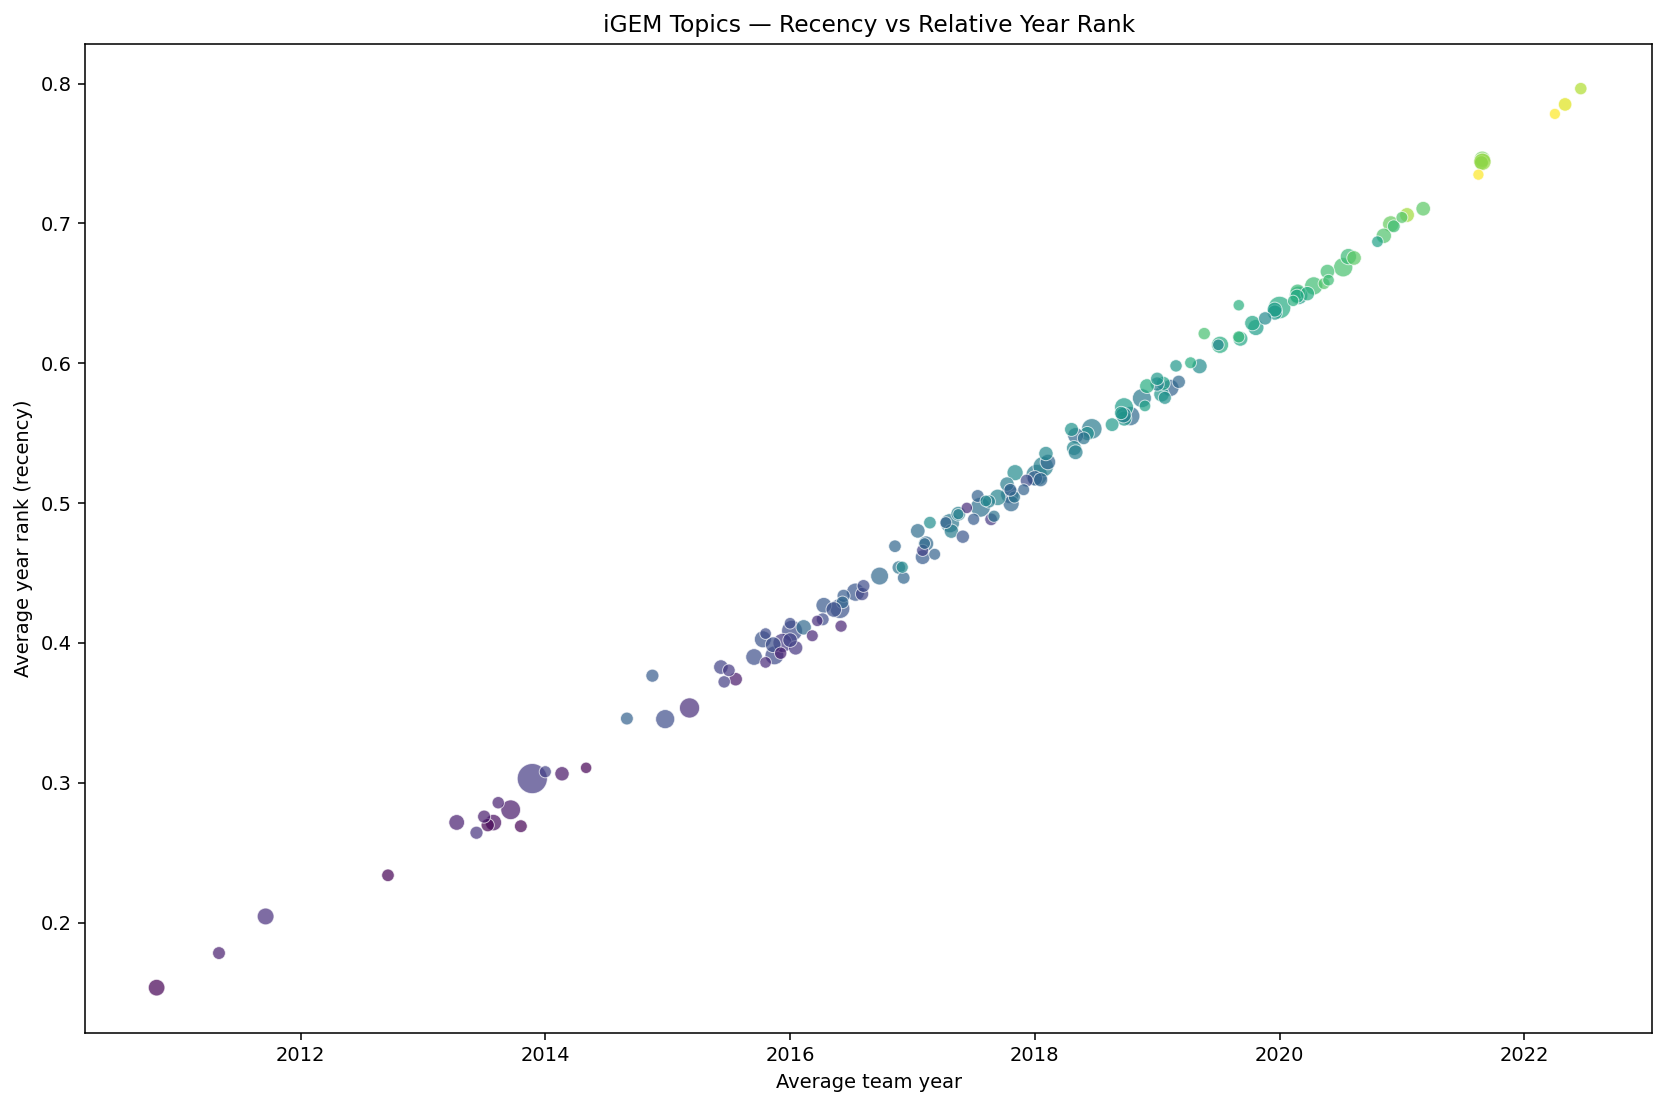

In [4]:
# Compact views: most recent and largest iGEM topics
print('Most recent topics (avg_year):')
display_cols = ['topic', 'global_name', 'n_teams', 'avg_year', 'median_year', 'price_index', 'avg_year_rank']
print(cluster_summary_igem.sort_values('avg_year', ascending=False)[display_cols].head(10).to_string(index=False))

print('\nLargest topics by teams:')
print(cluster_summary_igem.sort_values('n_teams', ascending=False)[display_cols].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8), dpi=140)
sizes = 20 + 220 * (cluster_summary_igem['n_teams'] / cluster_summary_igem['n_teams'].max())
ax.scatter(
    cluster_summary_igem['avg_year'],
    cluster_summary_igem['avg_year_rank'],
    s=sizes,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary_igem['price_index'],
    cmap='viridis',
)
ax.set_xlabel('Average team year')
ax.set_ylabel('Average year rank (recency)')
ax.set_title('iGEM Topics — Recency vs Relative Year Rank')
plt.tight_layout()
plt.show()